In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load the dataset
df = pd.read_csv('insurance.csv')

# Display basic info
print(df.shape)
print(df.columns)
print(df.head())

(1338, 7)
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [2]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

print("\nData after encoding:")
print(df.head())

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Data after encoding:
   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520


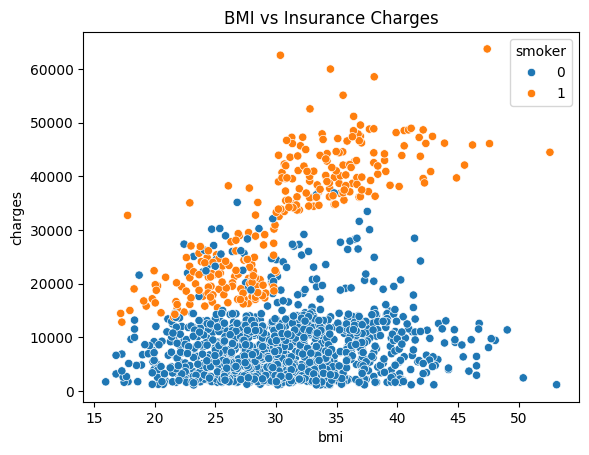

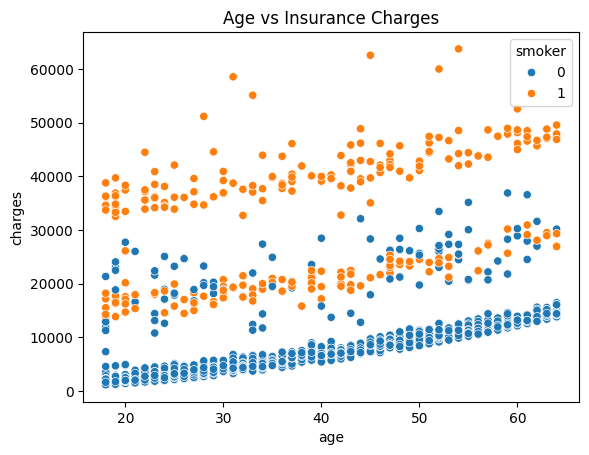

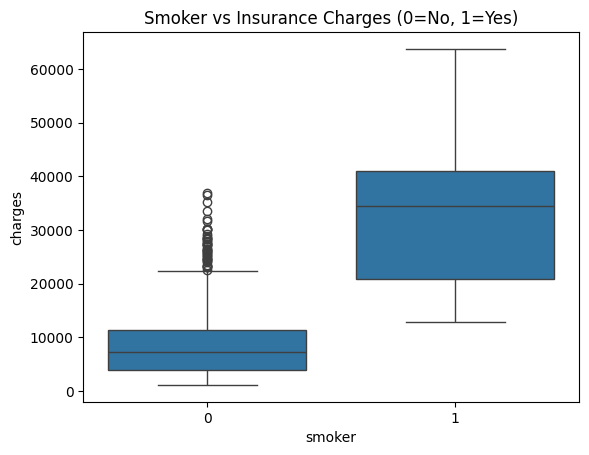

In [3]:
# BMI vs Charges
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker')
plt.title('BMI vs Insurance Charges')
plt.show()

# Age vs Charges
sns.scatterplot(data=df, x='age', y='charges', hue='smoker')
plt.title('Age vs Insurance Charges')
plt.show()

# Smoker vs Charges
sns.boxplot(data=df, x='smoker', y='charges')
plt.title('Smoker vs Insurance Charges (0=No, 1=Yes)')
plt.show()

In [4]:
# Define features and target
X = df.drop('charges', axis=1)
y = df['charges']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4186.508898366435
RMSE: 5799.587091438356


In [5]:
# Conclusion
print("""
Key Insights from Insurance Claim Prediction:
1. MAE: {:.2f}
2. RMSE: {:.2f}
3. Smokers pay significantly higher insurance charges
4. Age and BMI both positively impact charges
5. Higher BMI smokers have the highest charges
""".format(mae, rmse))


Key Insights from Insurance Claim Prediction:
1. MAE: 4186.51
2. RMSE: 5799.59
3. Smokers pay significantly higher insurance charges
4. Age and BMI both positively impact charges
5. Higher BMI smokers have the highest charges

